# 🌍 Satellite Image Classification using CNN

This project uses a Convolutional Neural Network (CNN) to classify satellite images into:

- 🌊 Water  
- 🌿 Green Area  
- 🏜 Desert  
- ☁ Cloudy  

## 🚀 Objective
To build a deep learning model that can classify satellite imagery for environmental and geographical analysis.

In [2]:
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob

## 📁 Dataset

The dataset consists of satellite images categorized into 4 classes:
- Water
- Green Area
- Desert
- Cloudy

Images are loaded from local directories and preprocessed before training.

In [5]:
water = glob.glob("data/water/*")
green_area = glob.glob("data/green_area/*")
desert = glob.glob("data/desert/*")
cloudy =  glob.glob("data/cloudy/*")

In [6]:
print("Number of images in Training are, water:",len(water ),",green_area",len(green_area))
print("Number of images in Training are, desert",len(desert),",cloudy",len(cloudy))

Number of images in Training are, water: 1500 ,green_area 1500
Number of images in Training are, desert 1131 ,cloudy 1500


## 🔄 Data Preprocessing

Steps performed:
- Image resizing
- Normalization
- Label encoding
- Train-test split

In [8]:

image = []
label = []

categories = [water, green_area, desert, cloudy]

for class_idx, category in enumerate(categories):
    for i in category:
        img = plt.imread(i)
        
       
        img = resize(img, (64,64,3))
        
        image.append(img)
        label.append(class_idx)


In [18]:
X = np.array(image)
y = np.array(label)

print("Dataset shape:", X.shape)

Dataset shape: (5631, 64, 64, 3)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4504, 64, 64, 3)
Test shape: (1127, 64, 64, 3)


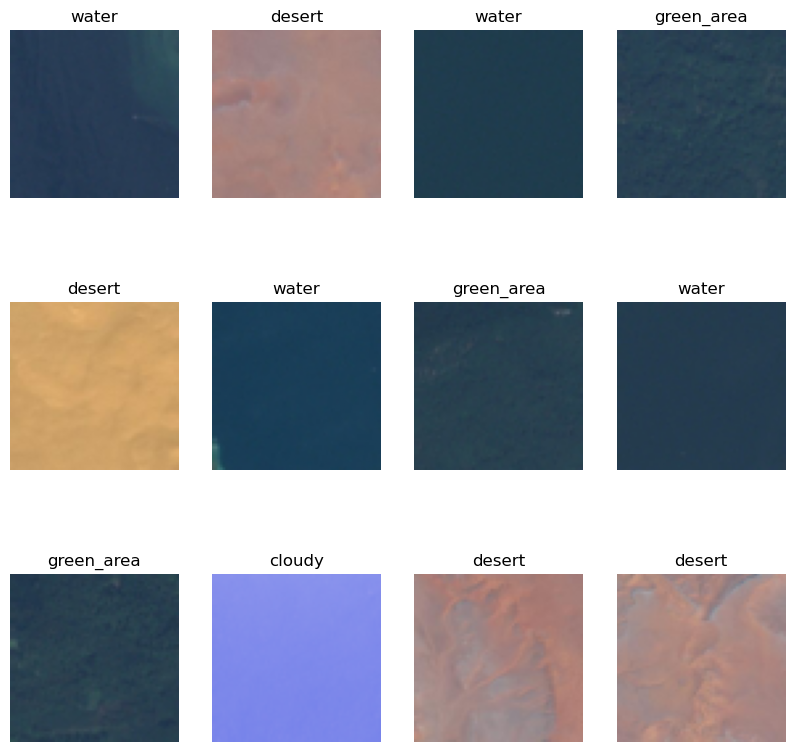

In [23]:
plt.figure(figsize=(10,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    
    # label names
    if y_train[i] == 0:
        plt.title("water")
    elif y_train[i] == 1:
        plt.title("green_area")
    elif y_train[i] == 2:
        plt.title("desert")
    else:
        plt.title("cloudy")
    
    plt.axis("off")

plt.show()

In [24]:
X_train.shape

(4504, 64, 64, 3)

In [25]:
y_train.shape

(4504,)

## 🧠 Model Architecture

The CNN model consists of:

- Conv2D layers for feature extraction  
- MaxPooling layers for dimensionality reduction  
- Dense layers for classification  
- Softmax activation for multi-class output  

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


model = Sequential()


model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(layers.MaxPooling2D((2,2)))


model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))


model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))


model.add(layers.Flatten())


model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))


model.add(layers.Dense(4, activation='softmax'))




C:\Users\jeswi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Model Training

The model is trained using:
- Loss: Categorical Crossentropy  
- Optimizer: Adam  
- Metrics: Accuracy  

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - accuracy: 0.7595 - loss: 0.4732 - val_accuracy: 0.8864 - val_loss: 0.2535
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9021 - loss: 0.2382 - val_accuracy: 0.9166 - val_loss: 0.1992
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9236 - loss: 0.1885 - val_accuracy: 0.9352 - val_loss: 0.1544
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9334 - loss: 0.1616 - val_accuracy: 0.9450 - val_loss: 0.1284
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9210 - loss: 0.1965 - val_accuracy: 0.9237 - val_loss: 0.1551
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9230 - loss: 0.1797 - val_accuracy: 0.9148 - val_loss: 0.1617
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9325 - loss: 0.1539 - val_accuracy: 0.9441 - val_loss: 0.1488
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.9298 - loss: 0.1609 - v

## 📊 Results & Evaluation

- Model performance is evaluated using accuracy  
- Confusion matrix is used to visualize predictions  

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9574 - loss: 0.1159
Test Loss: 0.11586686223745346
Test Accuracy: 0.9574090242385864


In [31]:
y_pred = model.predict(X_test)


y_pred_classes = np.argmax(y_pred, axis=1)

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step  


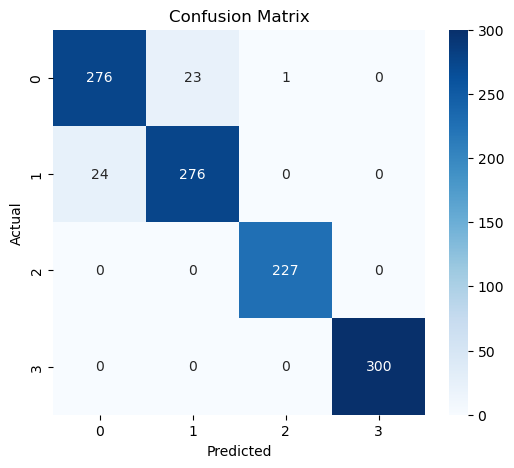

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## 🖼️ Prediction Visualization

Sample predictions from the model are visualized below:

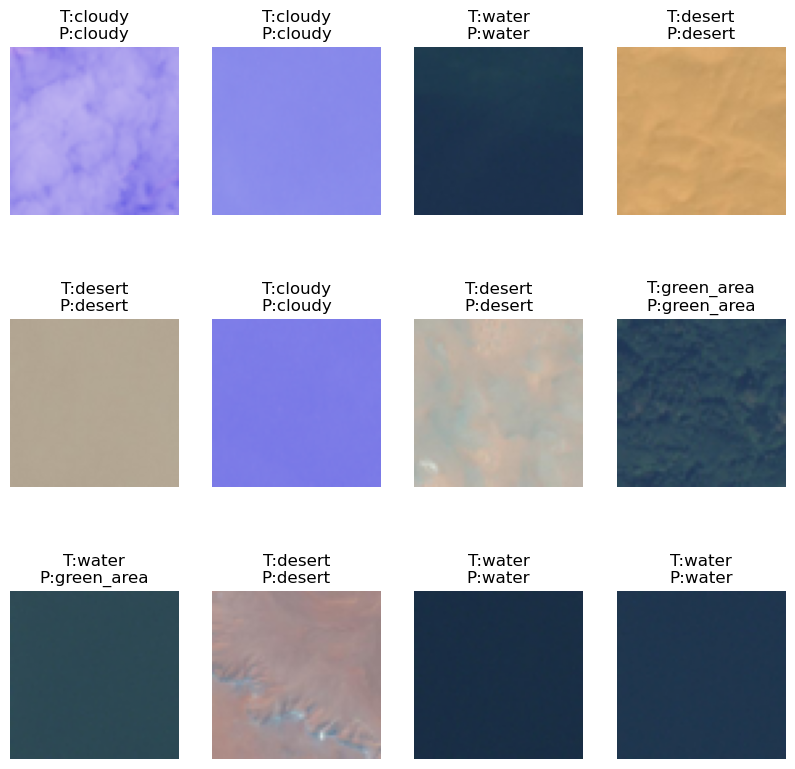

In [33]:
labels_map = ["water", "green_area", "desert", "cloudy"]

plt.figure(figsize=(10,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    
    true_label = labels_map[y_test[i]]
    pred_label = labels_map[y_pred_classes[i]]
    
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis("off")

plt.show()